In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zynicide/wine-reviews/winemag-data_first150k.csv
/kaggle/input/datasets/zynicide/wine-reviews/winemag-data-130k-v2.json
/kaggle/input/datasets/zynicide/wine-reviews/winemag-data-130k-v2.csv


In [2]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.1 MB/s eta 0:00:00


In [3]:
%%time
import re
import nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

CPU times: user 1.49 s, sys: 271 ms, total: 1.77 s
Wall time: 2.47 s


## Data Acq.

In [4]:
%%time
df = pd.read_csv("/kaggle/input/datasets/zynicide/wine-reviews/winemag-data_first150k.csv")
print(f'150k Df Shape : {df.shape}')

150k Df Shape : (150930, 11)
CPU times: user 672 ms, sys: 88.2 ms, total: 760 ms
Wall time: 955 ms


## NLTK Setup

In [5]:
%%time
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

CPU times: user 39.6 ms, sys: 18 ms, total: 57.6 ms
Wall time: 242 ms


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# 1. Basic Text Analysis

## 1.1. Data Samples

In [6]:
%%time
pd.set_option('display.max_colwidth', None)
df[["description"]].head()

CPU times: user 4.28 ms, sys: 1.05 ms, total: 5.33 ms
Wall time: 9.77 ms


,description
0,"This tremendous 100% varietal wine hails from Oakville and was aged over three years in oak. Juicy red-cherry fruit and a compelling hint of caramel greet the palate, framed by elegant, fine tannins and a subtle minty tone in the background. Balanced and rewarding from start to finish, it has years ahead of it to develop further nuance. Enjoy 2022–2030."
1,"Ripe aromas of fig, blackberry and cassis are softened and sweetened by a slathering of oaky chocolate and vanilla. This is full, layered, intense and cushioned on the palate, with rich flavors of chocolaty black fruits and baking spices. A toasty, everlasting finish is heady but ideally balanced. Drink through 2023."
2,"Mac Watson honors the memory of a wine once made by his mother in this tremendously delicious, balanced and complex botrytised white. Dark gold in color, it layers toasted hazelnut, pear compote and orange peel flavors, reveling in the succulence of its 122 g/L of residual sugar."
3,"This spent 20 months in 30% new French oak, and incorporates fruit from Ponzi's Aurora, Abetina and Madrona vineyards, among others. Aromatic, dense and toasty, it deftly blends aromas and flavors of toast, cigar box, blackberry, black cherry, coffee and graphite. Tannins are polished to a fine sheen, and frame a finish loaded with dark chocolate and espresso. Drink now through 2032."
4,"This is the top wine from La Bégude, named after the highest point in the vineyard at 1200 feet. It has structure, density and considerable acidity that is still calming down. With 18 months in wood, the wine has developing an extra richness and concentration. Produced by the Tari family, formerly of Château Giscours in Margaux, it is a wine made for aging. Drink from 2020."


## 1.2. Basic Stats

In [7]:
%%time
desc = df[["description", "points", "price"]].copy()

desc["char_count"] = desc["description"].str.len()
desc["word_count"] = desc["description"].str.split().str.len()
desc["sent_count"] = desc["description"].str.split('.').str.len()

print("=== Basic Description Stats ===")
desc[["char_count","word_count","sent_count"]].head(5)

=== Basic Description Stats ===
CPU times: user 1.24 s, sys: 203 ms, total: 1.44 s
Wall time: 1.44 s


,char_count,word_count,sent_count
0,355,60,5
1,318,51,5
2,280,47,3
3,386,62,5
4,376,66,6


## 1.3. Missing Value

In [8]:
%%time
missing = desc["description"].isna().sum()
print(f"\nMissing Values : {missing} ({missing/len(desc)*100}%)")


Missing Values : 0 (0.0%)
CPU times: user 19 ms, sys: 0 ns, total: 19 ms
Wall time: 18.6 ms


## 1.4. Word count distribution

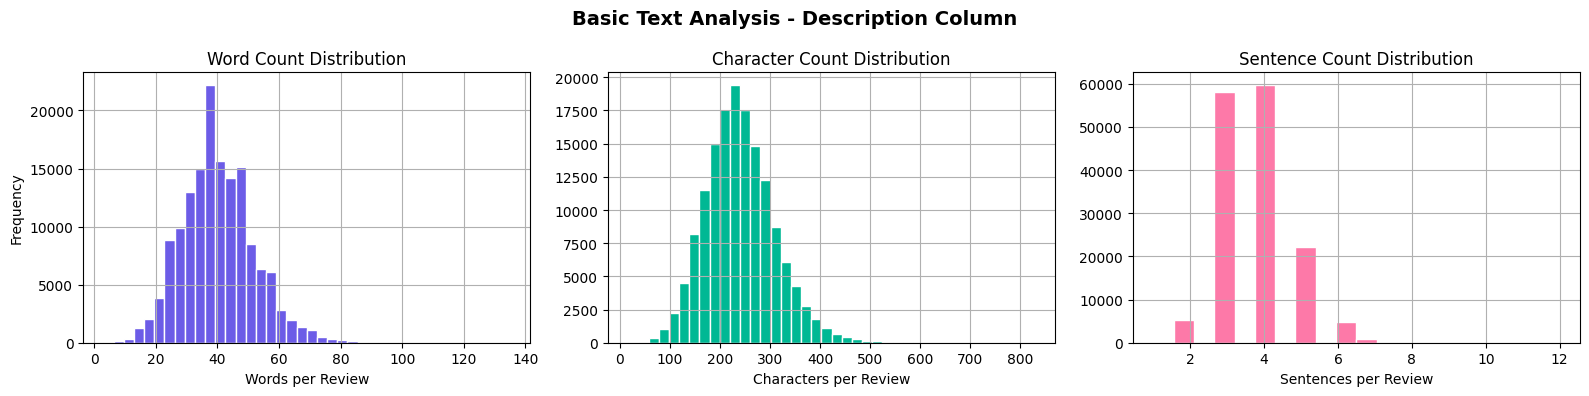

CPU times: user 450 ms, sys: 12.3 ms, total: 463 ms
Wall time: 490 ms


In [9]:
%%time
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Basic Text Analysis - Description Column", fontsize=14, fontweight='bold')

desc["word_count"].hist(bins=40, ax=axes[0], color="#6c5ce7", edgecolor='white')
axes[0].set_title("Word Count Distribution")
axes[0].set_xlabel("Words per Review")
axes[0].set_ylabel("Frequency")

desc["char_count"].hist(bins=40, ax=axes[1], color="#00b894", edgecolor='white')
axes[1].set_title("Character Count Distribution")
axes[1].set_xlabel("Characters per Review")

desc["sent_count"].hist(bins=20, ax=axes[2], color="#fd79a8", edgecolor='white')
axes[2].set_title("Sentence Count Distribution")
axes[2].set_xlabel("Sentences per Review")

plt.tight_layout()
plt.show()

## 1.5. Most Frequent Words

In [10]:
%%time
stop_words = set(stopwords.words('english'))
# domain specific to add to stop word
domain_stops = {"wine", "wines", "drink", "flavor", "flavors", "palate", 
                "finish", "nose", "aromas", "notes", "offers", "shows"}
stop_words.update(domain_stops)

def get_tokens(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    tokens = word_tokenize(text)
    # eliminate the text if exist on stopwords and word with only 2 or less chars
    return [t for t in tokens if t not in stop_words and len(t) > 2]

print("\nTokenizing... (might take a moment)")
desc["tokens"] = desc["description"].apply(get_tokens)

all_words = [word for tokens in desc["tokens"] for word in tokens]
word_freq  = Counter(all_words)
top_words  = word_freq.most_common(20)


Tokenizing... (might take a moment)
CPU times: user 16.4 s, sys: 133 ms, total: 16.5 s
Wall time: 16.5 s


## 1.6. Bar chart top words

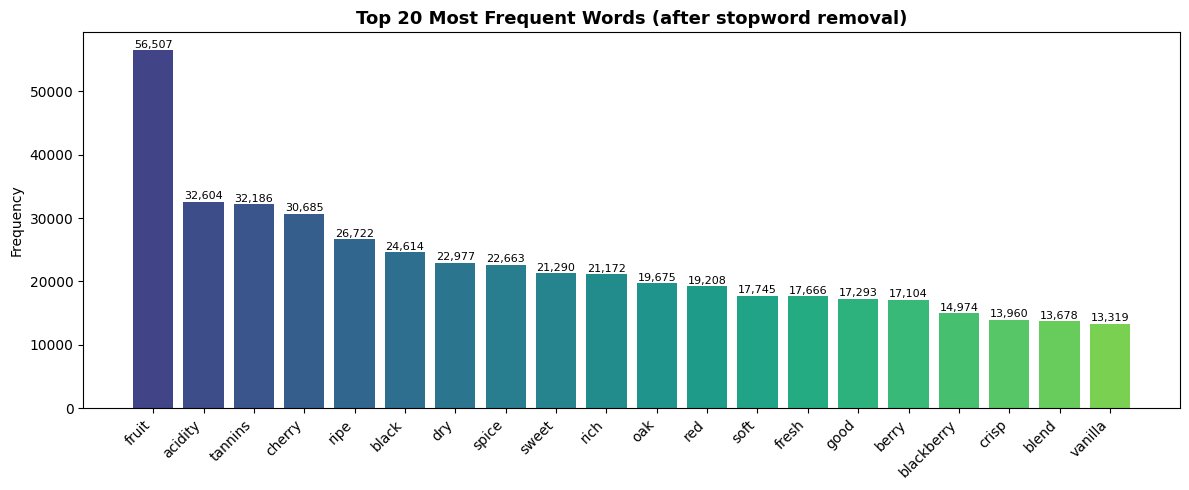

CPU times: user 223 ms, sys: 5.09 ms, total: 228 ms
Wall time: 227 ms


In [11]:
%%time
words, counts = zip(*top_words)

plt.figure(figsize=(12, 5))
bars = plt.bar(words, counts, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(words))))
plt.title("Top 20 Most Frequent Words (after stopword removal)", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency")
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
%%time
desc[["tokens"]].head()

CPU times: user 5.2 ms, sys: 8 µs, total: 5.2 ms
Wall time: 5.01 ms


,tokens
0,"[tremendous, varietal, hails, oakville, aged, three, years, oak, juicy, redcherry, fruit, compelling, hint, caramel, greet, framed, elegant, fine, tannins, subtle, minty, tone, background, balanced, rewarding, start, years, ahead, develop, nuance, enjoy]"
1,"[ripe, fig, blackberry, cassis, softened, sweetened, slathering, oaky, chocolate, vanilla, full, layered, intense, cushioned, rich, chocolaty, black, fruits, baking, spices, toasty, everlasting, heady, ideally, balanced]"
2,"[mac, watson, honors, memory, made, mother, tremendously, delicious, balanced, complex, botrytised, white, dark, gold, color, layers, toasted, hazelnut, pear, compote, orange, peel, reveling, succulence, residual, sugar]"
3,"[spent, months, new, french, oak, incorporates, fruit, ponzis, aurora, abetina, madrona, vineyards, among, others, aromatic, dense, toasty, deftly, blends, toast, cigar, box, blackberry, black, cherry, coffee, graphite, tannins, polished, fine, sheen, frame, loaded, dark, chocolate, espresso]"
4,"[top, bgude, named, highest, point, vineyard, feet, structure, density, considerable, acidity, still, calming, months, wood, developing, extra, richness, concentration, produced, tari, family, formerly, chteau, giscours, margaux, made, aging]"


## 1.7. Summary

In [13]:
%%time
print("\n=== Summary ===")
print(f"Total reviews      : {len(desc):,}")
print(f"Avg words/review   : {desc['word_count'].mean():.1f}")
print(f"Avg chars/review   : {desc['char_count'].mean():.1f}")
print(f"Unique words       : {len(word_freq):,}")
print(f"Top 5 words        : {[w for w, _ in top_words[:5]]}")


=== Summary ===
Total reviews      : 150,930
Avg words/review   : 40.2
Avg chars/review   : 240.4
Unique words       : 42,517
Top 5 words        : ['fruit', 'acidity', 'tannins', 'cherry', 'ripe']
CPU times: user 1.16 ms, sys: 8 µs, total: 1.17 ms
Wall time: 793 µs


# 2. Sentiment Analysis
Sentiment analysis is the process of computationally identifying and categorizing the emotional tone expressed in a piece of text — whether it is positive, negative, or neutral.

In this section, we use two tools to analyze the sentiment of wine review descriptions:

### A. TextBlob

TextBlob produces two values:

**Polarity** — measures how positive or negative the text is, on a scale from -1.0 to +1.0.
- `-1.0` = very negative
- `0.0` = neutral
- `+1.0` = very positive

**Subjectivity** — measures how subjective or objective the text is, on a scale from 0.0 to 1.0.
- `0.0` = very objective (factual)
- `1.0` = very subjective (opinion-based)

### B. VADER (Valence Aware Dictionary and sEntiment Reasoner)

VADER is specifically designed for short, social-media-style text but works well on review data too. It produces a **compound score** — a single normalized value between -1.0 and +1.0 that summarizes the overall sentiment of the text.

| Compound Score | Label    |
|----------------|----------|
| >= 0.05        | Positive |
| <= -0.05       | Negative |
| between        | Neutral  |

### Why does this matter?

We want to explore whether reviews with a **higher polarity or compound score** tend to receive **higher points**. If a strong correlation exists, sentiment scores could become useful features in our machine learning model later.

### C. TextBlob vs VADER

Both TextBlob and VADER measure positive and negative sentiment, but they work in fundamentally different ways.

**TextBlob** uses a dictionary-based approach. It looks up each word individually in its lexicon and checks whether that word carries a positive or negative meaning. This makes it well-suited for formal, structured text.

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) is designed to understand context, not just individual words. It accounts for things like capitalization, punctuation, and intensifiers.

For example:
- `"great"` → positive
- `"GREAT!!!"` → VADER recognizes this as *more* positive than just `"great"`

This makes VADER generally better suited for review-style text.

---

### Why use both?

We do not know in advance which method will perform better on this specific dataset. By running both, we can:

1. **Cross-validate** — if both methods agree, we can be more confident in the result
2. **Compare correlation with points** — whichever score correlates more strongly with wine points is the more useful feature for our machine learning model later

This is not duplication — it is a deliberate strategy to let the data tell us which tool works best.

## 2.1. TextBlob Sentiment

In [14]:
%%time
print("Running TextBlob... (might take a moment)")
desc["polarity"]      = desc["description"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
desc["subjectivity"]  = desc["description"].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

Running TextBlob... (might take a moment)
CPU times: user 1min 13s, sys: 33.1 ms, total: 1min 13s
Wall time: 1min 13s


In [15]:
%%time
desc.head()

CPU times: user 126 µs, sys: 2 µs, total: 128 µs
Wall time: 131 µs


,description,points,price,char_count,word_count,sent_count,tokens,polarity,subjectivity
0,"This tremendous 100% varietal wine hails from Oakville and was aged over three years in oak. Juicy red-cherry fruit and a compelling hint of caramel greet the palate, framed by elegant, fine tannins and a subtle minty tone in the background. Balanced and rewarding from start to finish, it has years ahead of it to develop further nuance. Enjoy 2022–2030.",96,235.0,355,60,5,"[tremendous, varietal, hails, oakville, aged, three, years, oak, juicy, redcherry, fruit, compelling, hint, caramel, greet, framed, elegant, fine, tannins, subtle, minty, tone, background, balanced, rewarding, start, years, ahead, develop, nuance, enjoy]",0.224074,0.666667
1,"Ripe aromas of fig, blackberry and cassis are softened and sweetened by a slathering of oaky chocolate and vanilla. This is full, layered, intense and cushioned on the palate, with rich flavors of chocolaty black fruits and baking spices. A toasty, everlasting finish is heady but ideally balanced. Drink through 2023.",96,110.0,318,51,5,"[ripe, fig, blackberry, cassis, softened, sweetened, slathering, oaky, chocolate, vanilla, full, layered, intense, cushioned, rich, chocolaty, black, fruits, baking, spices, toasty, everlasting, heady, ideally, balanced]",0.331667,0.746667
2,"Mac Watson honors the memory of a wine once made by his mother in this tremendously delicious, balanced and complex botrytised white. Dark gold in color, it layers toasted hazelnut, pear compote and orange peel flavors, reveling in the succulence of its 122 g/L of residual sugar.",96,90.0,280,47,3,"[mac, watson, honors, memory, made, mother, tremendously, delicious, balanced, complex, botrytised, white, dark, gold, color, layers, toasted, hazelnut, pear, compote, orange, peel, reveling, succulence, residual, sugar]",0.137500,0.450000
3,"This spent 20 months in 30% new French oak, and incorporates fruit from Ponzi's Aurora, Abetina and Madrona vineyards, among others. Aromatic, dense and toasty, it deftly blends aromas and flavors of toast, cigar box, blackberry, black cherry, coffee and graphite. Tannins are polished to a fine sheen, and frame a finish loaded with dark chocolate and espresso. Drink now through 2032.",96,65.0,386,62,5,"[spent, months, new, french, oak, incorporates, fruit, ponzis, aurora, abetina, madrona, vineyards, among, others, aromatic, dense, toasty, deftly, blends, toast, cigar, box, blackberry, black, cherry, coffee, graphite, tannins, polished, fine, sheen, frame, loaded, dark, chocolate, espresso]",0.105195,0.398268
4,"This is the top wine from La Bégude, named after the highest point in the vineyard at 1200 feet. It has structure, density and considerable acidity that is still calming down. With 18 months in wood, the wine has developing an extra richness and concentration. Produced by the Tari family, formerly of Château Giscours in Margaux, it is a wine made for aging. Drink from 2020.",95,66.0,376,66,6,"[top, bgude, named, highest, point, vineyard, feet, structure, density, considerable, acidity, still, calming, months, wood, developing, extra, richness, concentration, produced, tari, family, formerly, chteau, giscours, margaux, made, aging]",0.088889,0.267778


## 2.2 VADER Sentiment

In [16]:
%%time
print("Running VADER...")
analyzer = SentimentIntensityAnalyzer()
desc["vader_compound"] = desc["description"].apply(lambda x: analyzer.polarity_scores(str(x))["compound"])
desc["vader_pos"]      = desc["description"].apply(lambda x: analyzer.polarity_scores(str(x))["pos"])
desc["vader_neg"]      = desc["description"].apply(lambda x: analyzer.polarity_scores(str(x))["neg"])
desc["vader_neu"]      = desc["description"].apply(lambda x: analyzer.polarity_scores(str(x))["neu"])

Running VADER...
CPU times: user 1min 3s, sys: 10.7 ms, total: 1min 3s
Wall time: 1min 3s


In [17]:
desc.head()

,description,points,price,char_count,word_count,sent_count,tokens,polarity,subjectivity,vader_compound,vader_pos,vader_neg,vader_neu
0,"This tremendous 100% varietal wine hails from Oakville and was aged over three years in oak. Juicy red-cherry fruit and a compelling hint of caramel greet the palate, framed by elegant, fine tannins and a subtle minty tone in the background. Balanced and rewarding from start to finish, it has years ahead of it to develop further nuance. Enjoy 2022–2030.",96,235.0,355,60,5,"[tremendous, varietal, hails, oakville, aged, three, years, oak, juicy, redcherry, fruit, compelling, hint, caramel, greet, framed, elegant, fine, tannins, subtle, minty, tone, background, balanced, rewarding, start, years, ahead, develop, nuance, enjoy]",0.224074,0.666667,0.9287,0.225,0.0,0.775
1,"Ripe aromas of fig, blackberry and cassis are softened and sweetened by a slathering of oaky chocolate and vanilla. This is full, layered, intense and cushioned on the palate, with rich flavors of chocolaty black fruits and baking spices. A toasty, everlasting finish is heady but ideally balanced. Drink through 2023.",96,110.0,318,51,5,"[ripe, fig, blackberry, cassis, softened, sweetened, slathering, oaky, chocolate, vanilla, full, layered, intense, cushioned, rich, chocolaty, black, fruits, baking, spices, toasty, everlasting, heady, ideally, balanced]",0.331667,0.746667,0.7311,0.130,0.0,0.870
2,"Mac Watson honors the memory of a wine once made by his mother in this tremendously delicious, balanced and complex botrytised white. Dark gold in color, it layers toasted hazelnut, pear compote and orange peel flavors, reveling in the succulence of its 122 g/L of residual sugar.",96,90.0,280,47,3,"[mac, watson, honors, memory, made, mother, tremendously, delicious, balanced, complex, botrytised, white, dark, gold, color, layers, toasted, hazelnut, pear, compote, orange, peel, reveling, succulence, residual, sugar]",0.137500,0.450000,0.8070,0.139,0.0,0.861
3,"This spent 20 months in 30% new French oak, and incorporates fruit from Ponzi's Aurora, Abetina and Madrona vineyards, among others. Aromatic, dense and toasty, it deftly blends aromas and flavors of toast, cigar box, blackberry, black cherry, coffee and graphite. Tannins are polished to a fine sheen, and frame a finish loaded with dark chocolate and espresso. Drink now through 2032.",96,65.0,386,62,5,"[spent, months, new, french, oak, incorporates, fruit, ponzis, aurora, abetina, madrona, vineyards, among, others, aromatic, dense, toasty, deftly, blends, toast, cigar, box, blackberry, black, cherry, coffee, graphite, tannins, polished, fine, sheen, frame, loaded, dark, chocolate, espresso]",0.105195,0.398268,0.2023,0.029,0.0,0.971
4,"This is the top wine from La Bégude, named after the highest point in the vineyard at 1200 feet. It has structure, density and considerable acidity that is still calming down. With 18 months in wood, the wine has developing an extra richness and concentration. Produced by the Tari family, formerly of Château Giscours in Margaux, it is a wine made for aging. Drink from 2020.",95,66.0,376,66,6,"[top, bgude, named, highest, point, vineyard, feet, structure, density, considerable, acidity, still, calming, months, wood, developing, extra, richness, concentration, produced, tari, family, formerly, chteau, giscours, margaux, made, aging]",0.088889,0.267778,0.7717,0.109,0.0,0.891


## 2.3. Label Sentiment

In [18]:
%%time
def label_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

desc["sentiment_label"] = desc["vader_compound"].apply(label_sentiment)
desc.head()

CPU times: user 24.5 ms, sys: 0 ns, total: 24.5 ms
Wall time: 24.2 ms


,description,points,price,char_count,word_count,sent_count,tokens,polarity,subjectivity,vader_compound,vader_pos,vader_neg,vader_neu,sentiment_label
0,"This tremendous 100% varietal wine hails from Oakville and was aged over three years in oak. Juicy red-cherry fruit and a compelling hint of caramel greet the palate, framed by elegant, fine tannins and a subtle minty tone in the background. Balanced and rewarding from start to finish, it has years ahead of it to develop further nuance. Enjoy 2022–2030.",96,235.0,355,60,5,"[tremendous, varietal, hails, oakville, aged, three, years, oak, juicy, redcherry, fruit, compelling, hint, caramel, greet, framed, elegant, fine, tannins, subtle, minty, tone, background, balanced, rewarding, start, years, ahead, develop, nuance, enjoy]",0.224074,0.666667,0.9287,0.225,0.0,0.775,Positive
1,"Ripe aromas of fig, blackberry and cassis are softened and sweetened by a slathering of oaky chocolate and vanilla. This is full, layered, intense and cushioned on the palate, with rich flavors of chocolaty black fruits and baking spices. A toasty, everlasting finish is heady but ideally balanced. Drink through 2023.",96,110.0,318,51,5,"[ripe, fig, blackberry, cassis, softened, sweetened, slathering, oaky, chocolate, vanilla, full, layered, intense, cushioned, rich, chocolaty, black, fruits, baking, spices, toasty, everlasting, heady, ideally, balanced]",0.331667,0.746667,0.7311,0.130,0.0,0.870,Positive
2,"Mac Watson honors the memory of a wine once made by his mother in this tremendously delicious, balanced and complex botrytised white. Dark gold in color, it layers toasted hazelnut, pear compote and orange peel flavors, reveling in the succulence of its 122 g/L of residual sugar.",96,90.0,280,47,3,"[mac, watson, honors, memory, made, mother, tremendously, delicious, balanced, complex, botrytised, white, dark, gold, color, layers, toasted, hazelnut, pear, compote, orange, peel, reveling, succulence, residual, sugar]",0.137500,0.450000,0.8070,0.139,0.0,0.861,Positive
3,"This spent 20 months in 30% new French oak, and incorporates fruit from Ponzi's Aurora, Abetina and Madrona vineyards, among others. Aromatic, dense and toasty, it deftly blends aromas and flavors of toast, cigar box, blackberry, black cherry, coffee and graphite. Tannins are polished to a fine sheen, and frame a finish loaded with dark chocolate and espresso. Drink now through 2032.",96,65.0,386,62,5,"[spent, months, new, french, oak, incorporates, fruit, ponzis, aurora, abetina, madrona, vineyards, among, others, aromatic, dense, toasty, deftly, blends, toast, cigar, box, blackberry, black, cherry, coffee, graphite, tannins, polished, fine, sheen, frame, loaded, dark, chocolate, espresso]",0.105195,0.398268,0.2023,0.029,0.0,0.971,Positive
4,"This is the top wine from La Bégude, named after the highest point in the vineyard at 1200 feet. It has structure, density and considerable acidity that is still calming down. With 18 months in wood, the wine has developing an extra richness and concentration. Produced by the Tari family, formerly of Château Giscours in Margaux, it is a wine made for aging. Drink from 2020.",95,66.0,376,66,6,"[top, bgude, named, highest, point, vineyard, feet, structure, density, considerable, acidity, still, calming, months, wood, developing, extra, richness, concentration, produced, tari, family, formerly, chteau, giscours, margaux, made, aging]",0.088889,0.267778,0.7717,0.109,0.0,0.891,Positive


## 2.4. Sentiment Distribution

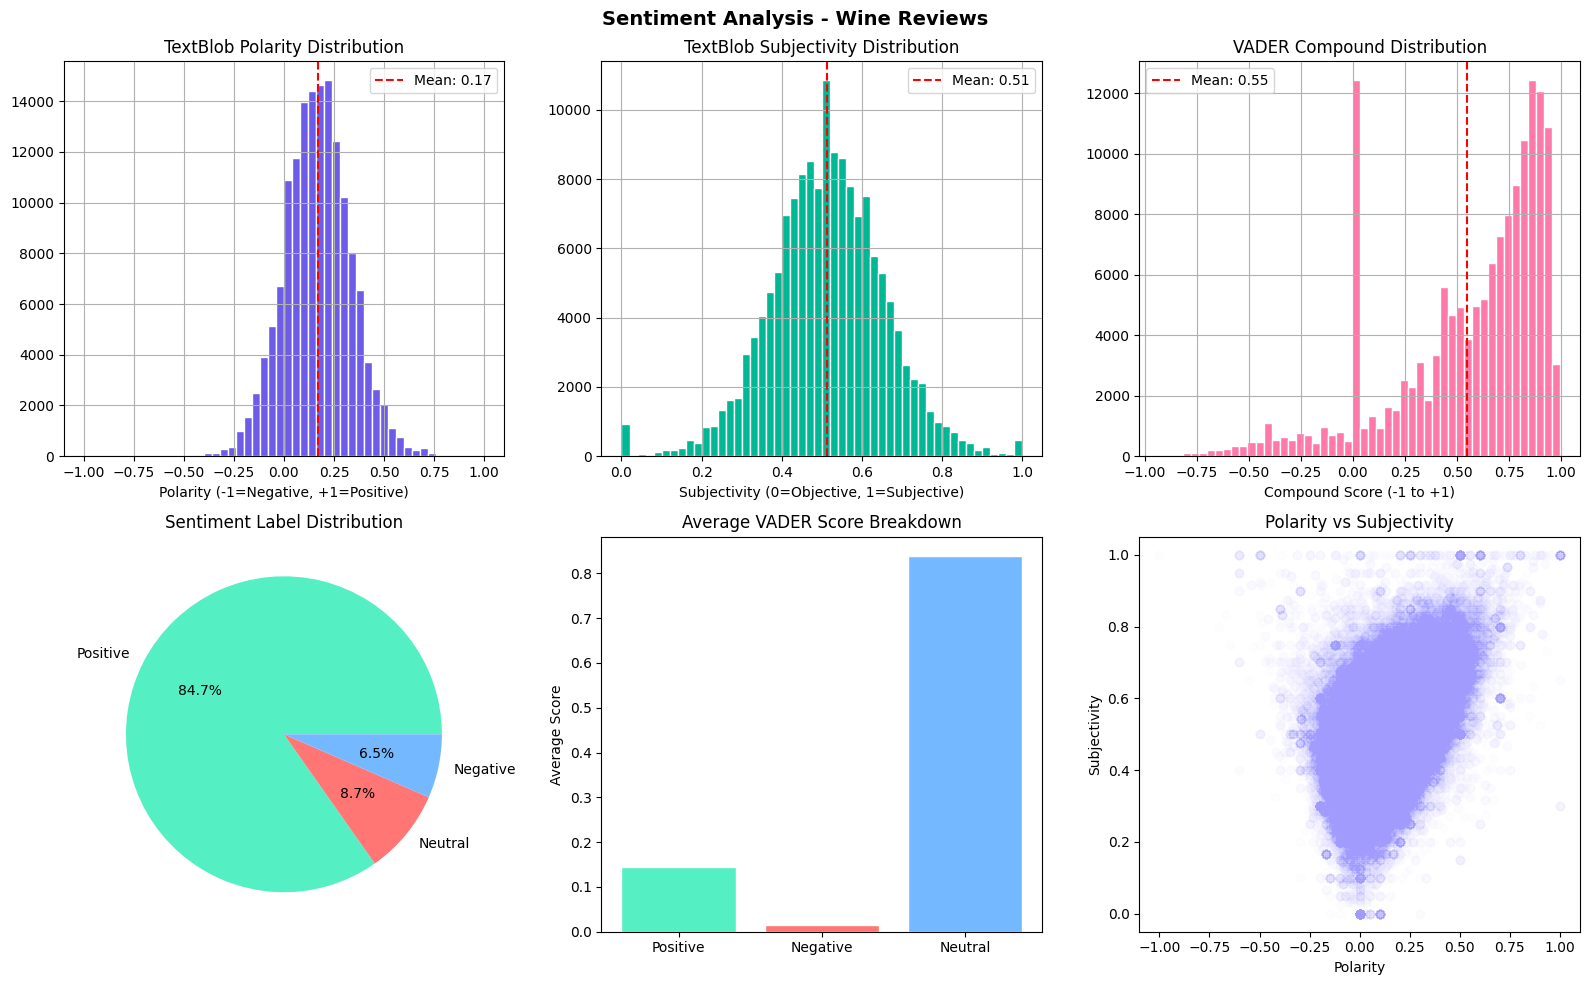

CPU times: user 1.01 s, sys: 18 ms, total: 1.03 s
Wall time: 1.04 s


In [19]:
%%time
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Sentiment Analysis - Wine Reviews", fontsize=14, fontweight='bold')

# Polarity distribution
desc["polarity"].hist(bins=50, ax=axes[0,0], color="#6c5ce7", edgecolor='white')
axes[0,0].set_title("TextBlob Polarity Distribution")
axes[0,0].set_xlabel("Polarity (-1=Negative, +1=Positive)")
axes[0,0].axvline(desc["polarity"].mean(), color='red', linestyle='--', label=f'Mean: {desc["polarity"].mean():.2f}')
axes[0,0].legend()

# Subjectivity distribution
desc["subjectivity"].hist(bins=50, ax=axes[0,1], color="#00b894", edgecolor='white')
axes[0,1].set_title("TextBlob Subjectivity Distribution")
axes[0,1].set_xlabel("Subjectivity (0=Objective, 1=Subjective)")
axes[0,1].axvline(desc["subjectivity"].mean(), color='red', linestyle='--', label=f'Mean: {desc["subjectivity"].mean():.2f}')
axes[0,1].legend()

# VADER compound distribution
desc["vader_compound"].hist(bins=50, ax=axes[0,2], color="#fd79a8", edgecolor='white')
axes[0,2].set_title("VADER Compound Distribution")
axes[0,2].set_xlabel("Compound Score (-1 to +1)")
axes[0,2].axvline(desc["vader_compound"].mean(), color='red', linestyle='--', label=f'Mean: {desc["vader_compound"].mean():.2f}')
axes[0,2].legend()

# Sentiment label pie chart
sentiment_counts = desc["sentiment_label"].value_counts()
axes[1,0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
              colors=["#55efc4", "#ff7675", "#74b9ff"])
axes[1,0].set_title("Sentiment Label Distribution")

# VADER pos/neg/neu bar
vader_means = desc[["vader_pos", "vader_neg", "vader_neu"]].mean()
axes[1,1].bar(["Positive", "Negative", "Neutral"], vader_means.values,
              color=["#55efc4", "#ff7675", "#74b9ff"], edgecolor='white')
axes[1,1].set_title("Average VADER Score Breakdown")
axes[1,1].set_ylabel("Average Score")

# Polarity vs Subjectivity scatter
axes[1,2].scatter(desc["polarity"], desc["subjectivity"], alpha=0.01, color="#a29bfe")
axes[1,2].set_title("Polarity vs Subjectivity")
axes[1,2].set_xlabel("Polarity")
axes[1,2].set_ylabel("Subjectivity")

plt.tight_layout()
plt.show()

## 2.5. Correlation Matrix
### Pearson correlation

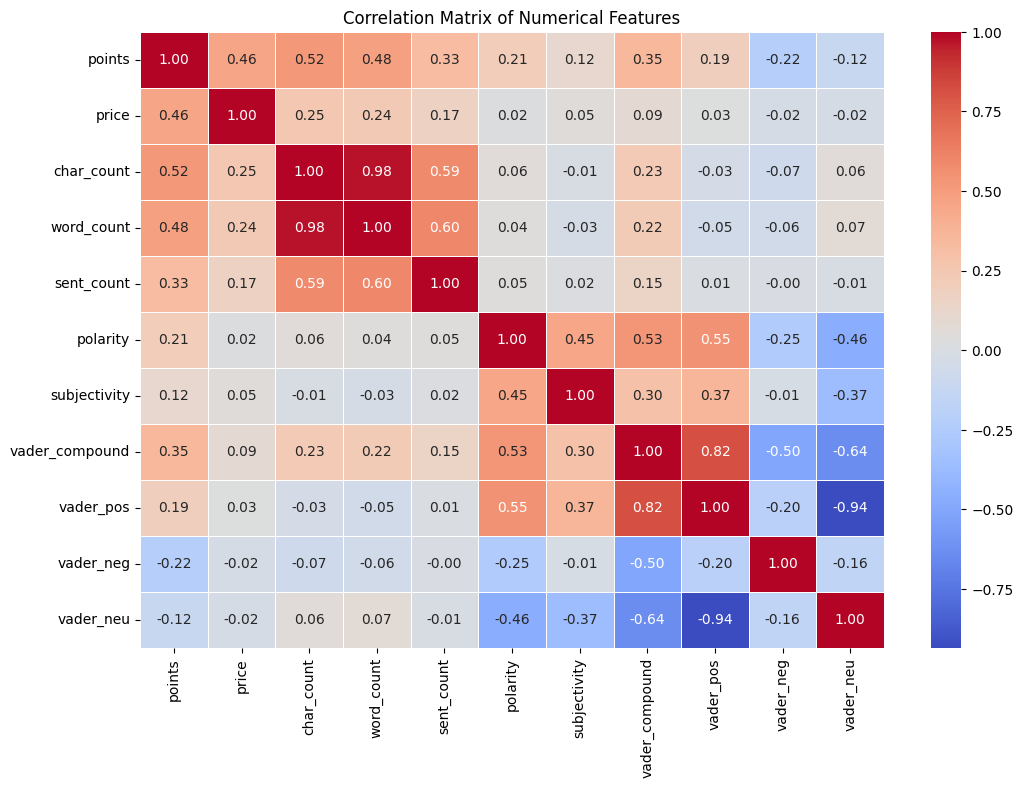

CPU times: user 335 ms, sys: 18 ms, total: 353 ms
Wall time: 354 ms


In [20]:
%%time
plt.figure(figsize=(12,8))

corr_matrix = desc.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()


=== Korelasi Sentiment vs Points ===
polarity          0.207
subjectivity      0.115
vader_compound    0.353
Name: points, dtype: float64


<Figure size 800x500 with 0 Axes>

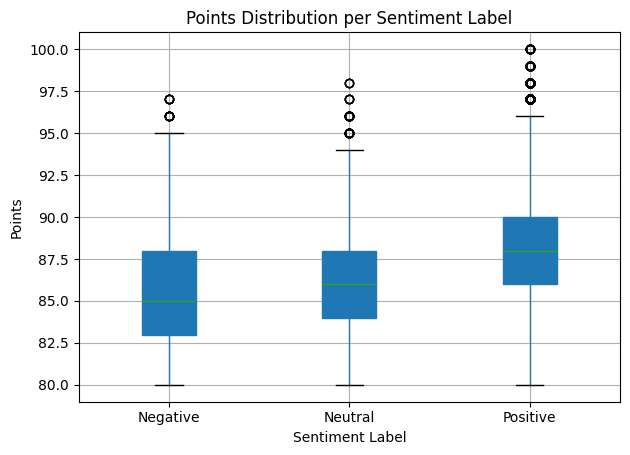

CPU times: user 211 ms, sys: 12 ms, total: 223 ms
Wall time: 222 ms


In [21]:
%%time
# Gabungkan dengan df asli untuk lihat korelasi dengan points
df_sentiment = df.join(desc[["polarity", "subjectivity", "vader_compound", "sentiment_label"]])

print("\n=== Korelasi Sentiment vs Points ===")
corr_cols = ["polarity", "subjectivity", "vader_compound", "points"]
print(df_sentiment[corr_cols].corr()["points"].drop("points").round(3))

# Boxplot points per sentiment label
plt.figure(figsize=(8, 5))
df_sentiment.boxplot(column="points", by="sentiment_label", 
                     patch_artist=True)
plt.suptitle("")
plt.title("Points Distribution per Sentiment Label")
plt.xlabel("Sentiment Label")
plt.ylabel("Points")
plt.tight_layout()
plt.show()

### Spearman Correlation

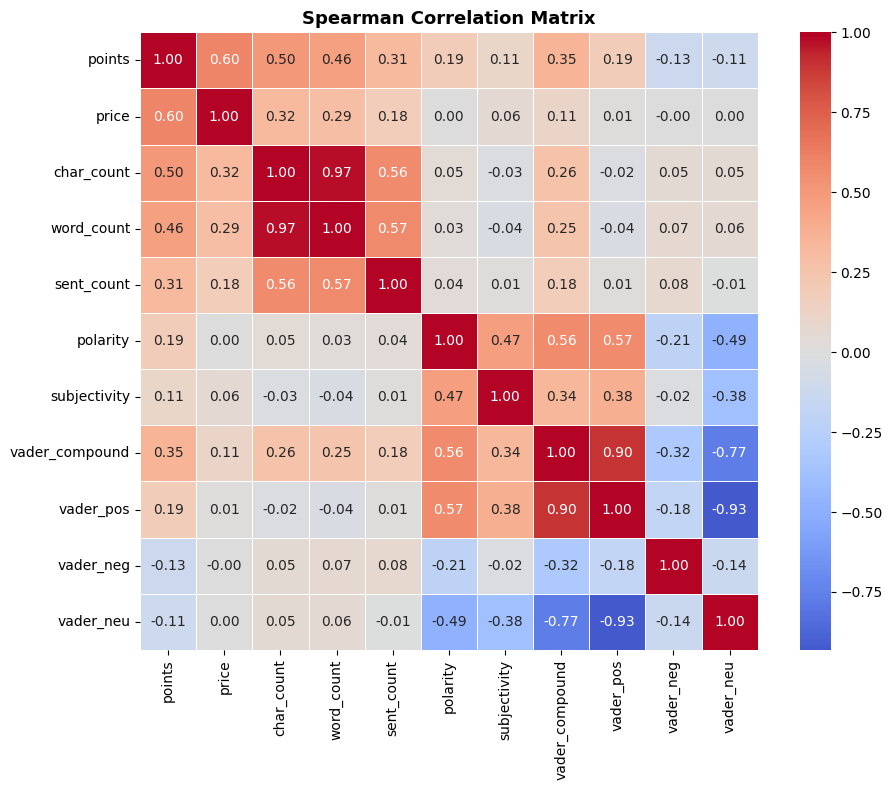

=== Spearman Correlation vs Points ===
price             0.596
char_count        0.499
word_count        0.459
vader_compound    0.354
sent_count        0.314
vader_pos         0.191
polarity          0.188
subjectivity      0.106
vader_neu        -0.114
vader_neg        -0.131
Name: points, dtype: float64
CPU times: user 684 ms, sys: 24 ms, total: 708 ms
Wall time: 710 ms


In [22]:
%%time
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ── Spearman Correlation Matrix ────────────────────────────────────────────────
cols = ["points", "price","char_count", "word_count", "sent_count", 
        "polarity", "subjectivity", "vader_compound", "vader_pos", "vader_neg", "vader_neu"]

df_corr = desc[cols].copy()

# Hitung spearman
spearman_matrix = df_corr.corr(method="spearman")

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Spearman Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print korelasi dengan points saja
print("=== Spearman Correlation vs Points ===")
print(spearman_matrix["points"].drop("points").sort_values(ascending=False).round(3))

## 2.6. Summary 

In [23]:
%%time
print("\n=== Summary ===")
print(f"Avg Polarity      : {desc['polarity'].mean():.3f}")
print(f"Avg Subjectivity  : {desc['subjectivity'].mean():.3f}")
print(f"Avg VADER compound: {desc['vader_compound'].mean():.3f}")
print(df_sentiment.groupby("sentiment_label")["points"].mean().round(2))


=== Summary ===
Avg Polarity      : 0.168
Avg Subjectivity  : 0.512
Avg VADER compound: 0.549
sentiment_label
Negative    85.42
Neutral     86.45
Positive    88.23
Name: points, dtype: float64
CPU times: user 8.99 ms, sys: 995 µs, total: 9.98 ms
Wall time: 11 ms


# 3. Topic Modelling

In [24]:
%%time
import gensim
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models
import warnings
warnings.filterwarnings("ignore")

CPU times: user 19.1 s, sys: 6 s, total: 25.1 s
Wall time: 29.1 s


## 3.1. Tokens Preparation

In [25]:
%%time
print(f"Documents total: {len(desc):,}")
print(f"Token example: {desc['tokens'].iloc[0]}")

Documents total: 150,930
Token example: ['tremendous', 'varietal', 'hails', 'oakville', 'aged', 'three', 'years', 'oak', 'juicy', 'redcherry', 'fruit', 'compelling', 'hint', 'caramel', 'greet', 'framed', 'elegant', 'fine', 'tannins', 'subtle', 'minty', 'tone', 'background', 'balanced', 'rewarding', 'start', 'years', 'ahead', 'develop', 'nuance', 'enjoy']
CPU times: user 192 µs, sys: 7 µs, total: 199 µs
Wall time: 178 µs


## 3.2. Build Dictionary & Corpus

In [26]:
%%time
# Dictionary → maps each unique word to a numeric ID
dictionary = corpora.Dictionary(desc["tokens"])

# Filter out words that are too rare or too common
# no_below=20  → ignore words that appear in fewer than 20 documents
# no_above=0.7 → ignore words that appear in more than 70% of documents
dictionary.filter_extremes(no_below=20, no_above=0.7)
print(f"\nVocabulary size after filtering: {len(dictionary):,}")

# Corpus → represents each document as a list of (word_id, frequency) pairs
# This is the format LDA expects as input
corpus = [dictionary.doc2bow(tokens) for tokens in desc["tokens"]]
print(f"Sample corpus[0]: {corpus[0][:5]}")


Vocabulary size after filtering: 7,144
Sample corpus[0]: [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1)]
CPU times: user 4.64 s, sys: 106 ms, total: 4.74 s
Wall time: 4.74 s


In [27]:
%%time
print(f'Dictionary total : {len(dictionary.token2id.items())}')

Dictionary total : 7144
CPU times: user 38 µs, sys: 0 ns, total: 38 µs
Wall time: 40.5 µs


## 3.3. Training LDA Model

### Topic Modeling with LDA

LDA (Latent Dirichlet Allocation) is an unsupervised method that automatically discovers hidden themes across a large collection of documents — without us telling it what the themes are.

#### Core Idea

LDA is built on two assumptions:

1. Every document is a **mix of topics**
2. Every topic is a **collection of words** that frequently appear together

For example, a wine review might be 60% about fruity flavors and 40% about structure and tannins — LDA captures this naturally.

#### How It Differs from Clustering

Unlike K-Means where each document belongs to exactly one cluster, LDA allows a document to belong to **multiple topics simultaneously** with different proportions. This makes it more realistic for text data.

#### Why Is It Useful Here?

After training, each review gets a **topic distribution** as new features:
```
review_1 → [topic_0: 0.6, topic_1: 0.1, topic_2: 0.3]
review_2 → [topic_0: 0.1, topic_1: 0.8, topic_2: 0.1]
```

These distributions are far more meaningful than raw word counts, and can potentially improve our machine learning model later.

> **Note:** LDA does not name the topics automatically. We interpret each topic manually by reading its top words and deciding what theme they represent.

In [28]:
%%time
NUM_TOPICS = 3  # bisa dicoba 4, 6, 8, 10

print(f"\nTraining LDA dengan {NUM_TOPICS} topics... (might take a moment)")

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=10,          # berapa kali iterasi seluruh corpus
    alpha="auto",       # distribusi topik per dokumen (auto = belajar sendiri)
    eta="auto"          # distribusi kata per topik (auto = belajar sendiri)
)

print("Training done!")


Training LDA dengan 3 topics... (might take a moment)


Training done!
CPU times: user 4min 33s, sys: 90.3 ms, total: 4min 33s
Wall time: 4min 33s


## 3.4. Top words each topics

In [29]:
%%time
print("\n=== Top Words per Topic ===")
for idx, topic in lda_model.print_topics(num_words=10):
    words = [w.split('"')[1] for w in topic.split("+")]
    print(f"\nTopic {idx}: {' | '.join(words)}")


=== Top Words per Topic ===

Topic 0: fruit | spice | cherry | mouth | berry | opens | red | imported | blend | tobacco

Topic 1: fruit | tannins | cherry | dry | oak | ripe | black | good | rich | red

Topic 2: fruit | acidity | crisp | citrus | apple | imported | fresh | peach | white | clean
CPU times: user 2.01 ms, sys: 2 µs, total: 2.02 ms
Wall time: 1.54 ms


## 3.5 Topic Distribution each documents

In [30]:
%%time
def get_dominant_topic(bow):
    topics = lda_model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0] if topics else -1

def get_topic_distribution(bow):
    topics = dict(lda_model.get_document_topics(bow))
    return [topics.get(i, 0.0) for i in range(NUM_TOPICS)]

print("\nMenghitung distribusi topik per dokumen...")
desc["dominant_topic"] = [get_dominant_topic(bow) for bow in corpus]

topic_dist = [get_topic_distribution(bow) for bow in corpus]
topic_dist_df = pd.DataFrame(topic_dist, columns=[f"topic_{i}" for i in range(NUM_TOPICS)])
desc = pd.concat([desc.reset_index(drop=True), topic_dist_df], axis=1)


Menghitung distribusi topik per dokumen...
CPU times: user 48.4 s, sys: 58.9 ms, total: 48.5 s
Wall time: 48.5 s
